In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../student_performance.csv")

print("Dataset loaded successfully")
print("Rows and Columns:", df.shape)

Dataset loaded successfully
Rows and Columns: (100, 10)


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (100, 10)

Column Names:
['Student_ID', 'Student_Name', 'Gender', 'City', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score', 'Result']

Data Types:
Student_ID         str
Student_Name       str
Gender             str
City               str
Study_Hours      int64
Attendance       int64
Math_Score       int64
Science_Score    int64
English_Score    int64
Result             str
dtype: object


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Student_ID       0
Student_Name     0
Gender           0
City             0
Study_Hours      0
Attendance       0
Math_Score       0
Science_Score    0
English_Score    0
Result           0
dtype: int64


In [6]:
print("Number of duplicate records:", df.duplicated().sum())


Number of duplicate records: 0


In [7]:
print("Descriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Study_Hours  Attendance  Math_Score  Science_Score  English_Score
count   100.000000  100.000000  100.000000     100.000000     100.000000
mean      5.270000   78.950000   71.130000      69.090000      72.170000
std       1.879474   11.358595   14.296044      12.746237      13.632296
min       2.000000   60.000000   39.000000      36.000000      39.000000
25%       4.000000   70.000000   61.000000      59.000000      62.000000
50%       5.000000   77.000000   71.000000      71.000000      73.500000
75%       7.000000   89.000000   83.000000      78.000000      82.250000
max       8.000000   98.000000   98.000000      97.000000      98.000000


In [9]:
# Select numerical columns
numeric_df = df[
    ["Study_Hours", "Attendance", "Math_Score",
     "Science_Score", "English_Score"]
]

# Calculate correlation
correlation = numeric_df.corr()

print("Correlation Matrix:")
print(correlation)


Correlation Matrix:
               Study_Hours  Attendance  Math_Score  Science_Score  \
Study_Hours       1.000000    0.005843    0.832128       0.779439   
Attendance        0.005843    1.000000    0.224724       0.186592   
Math_Score        0.832128    0.224724    1.000000       0.646282   
Science_Score     0.779439    0.186592    0.646282       1.000000   
English_Score     0.845015    0.211869    0.793297       0.720397   

               English_Score  
Study_Hours         0.845015  
Attendance          0.211869  
Math_Score          0.793297  
Science_Score       0.720397  
English_Score       1.000000  


In [10]:
# Calculate average score for each subject
average_scores = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

print("Average Scores:")
print(average_scores)

Average Scores:
Math_Score       71.13
Science_Score    69.09
English_Score    72.17
dtype: float64


In [11]:
# Check for outliers using IQR method

columns = [
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score"
]

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]
    
    print(column, ":", len(outliers), "outliers")
    

Study_Hours : 0 outliers
Attendance : 0 outliers
Math_Score : 0 outliers
Science_Score : 0 outliers
English_Score : 0 outliers


In [12]:
result_count = df["Result"].value_counts()

print("Student Count by Result:")
print(result_count)


Student Count by Result:
Result
Pass    99
Fail     1
Name: count, dtype: int64


In [13]:
city_count = df["City"].value_counts()

print("Student Count by City:")
print(city_count)

Student Count by City:
City
Amravati    27
Nashik      21
Mumbai      20
Nagpur      17
Pune        15
Name: count, dtype: int64


In [14]:
subject_average = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

print("Subject-wise Average Score:")
print(subject_average)

Subject-wise Average Score:
Math_Score       71.13
Science_Score    69.09
English_Score    72.17
dtype: float64


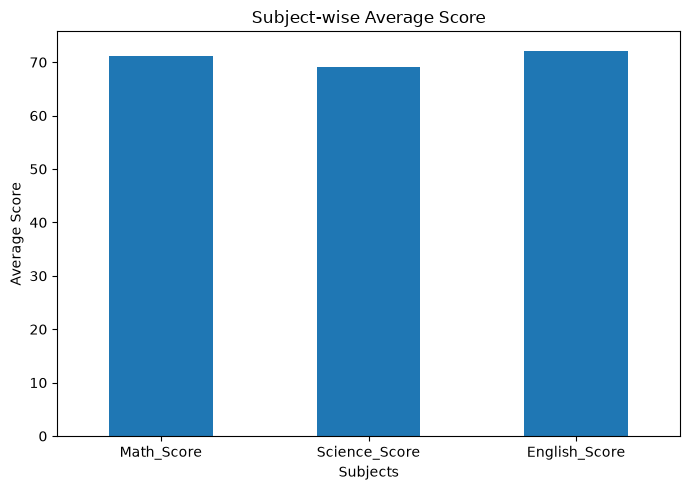

In [15]:
subject_average = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

plt.figure(figsize=(7, 5))
subject_average.plot(kind="bar")

plt.title("Subject-wise Average Score")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

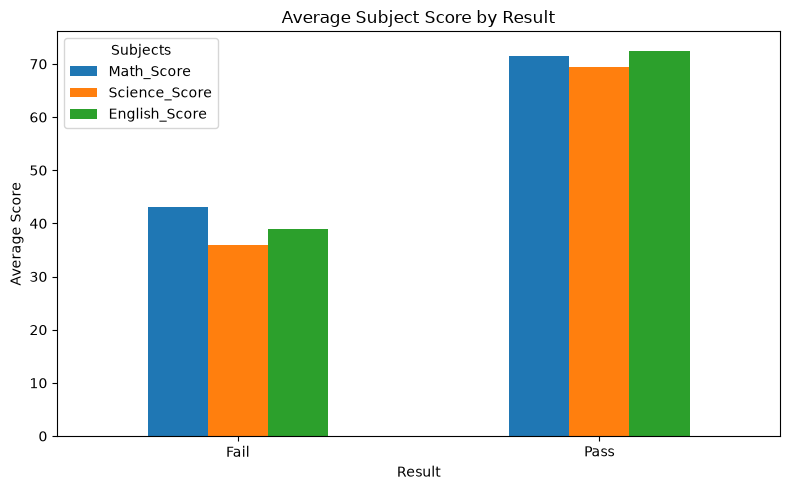

In [16]:
result_average = df.groupby("Result")[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

result_average.plot(kind="bar", figsize=(8, 5))

plt.title("Average Subject Score by Result")
plt.xlabel("Result")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.tight_layout()

plt.show()

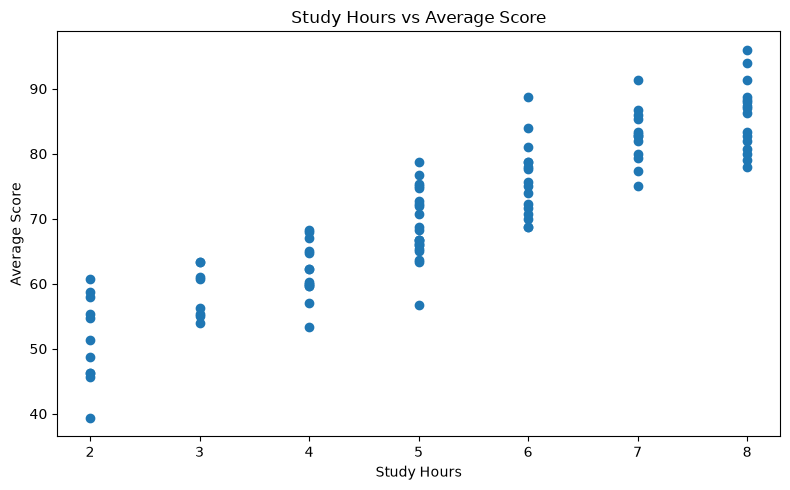

In [17]:
df["Average_Score"] = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean(axis=1)

plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Average_Score"])

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.tight_layout()

plt.show()

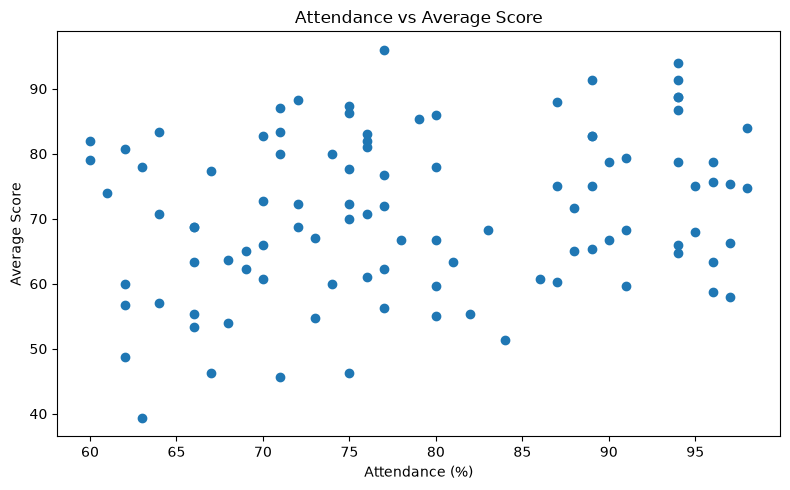

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Attendance"], df["Average_Score"])

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.tight_layout()

plt.show()


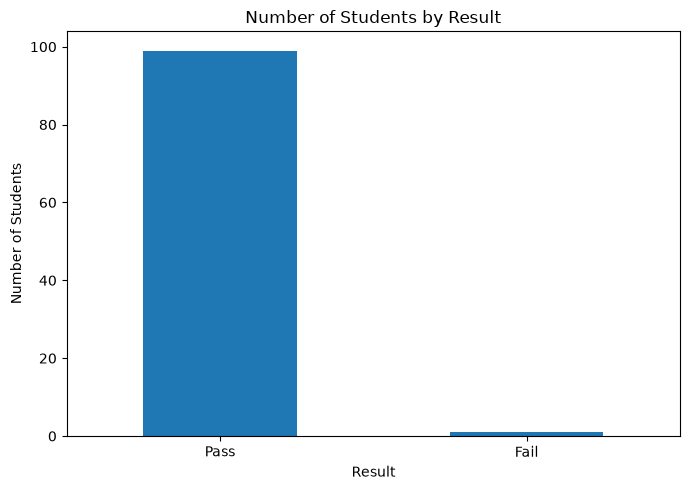

In [19]:
result_count = df["Result"].value_counts()

plt.figure(figsize=(7, 5))
result_count.plot(kind="bar")

plt.title("Number of Students by Result")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

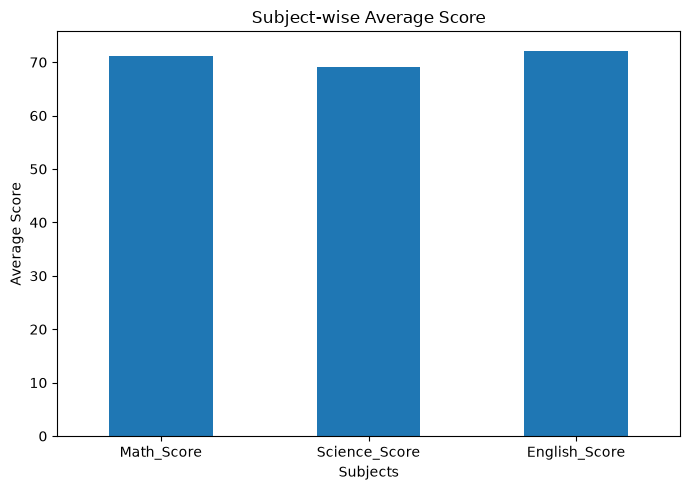

In [20]:
plt.figure(figsize=(7, 5))
subject_average.plot(kind="bar")

plt.title("Subject-wise Average Score")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/subject_average_score.png")
plt.show()

In [21]:
plt.savefig("../visualizations/average_score_by_result.png")

<Figure size 640x480 with 0 Axes>

In [22]:
plt.savefig("../visualizations/study_hours_vs_score.png")

<Figure size 640x480 with 0 Axes>

In [23]:
plt.savefig("../visualizations/attendance_vs_score.png")

<Figure size 640x480 with 0 Axes>

In [24]:
plt.savefig("../visualizations/students_by_result.png")

<Figure size 640x480 with 0 Axes>

In [25]:
plt.savefig("../visualizations/average_score_by_result.png")

<Figure size 640x480 with 0 Axes>

<Figure size 800x500 with 0 Axes>

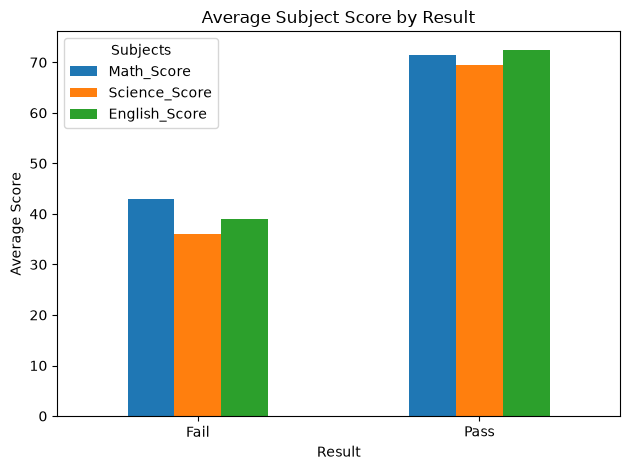

In [26]:
result_average = df.groupby("Result")[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

plt.figure(figsize=(8, 5))

result_average.plot(kind="bar")

plt.title("Average Subject Score by Result")
plt.xlabel("Result")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.tight_layout()

plt.savefig("../visualizations/average_score_by_result.png")
plt.show()

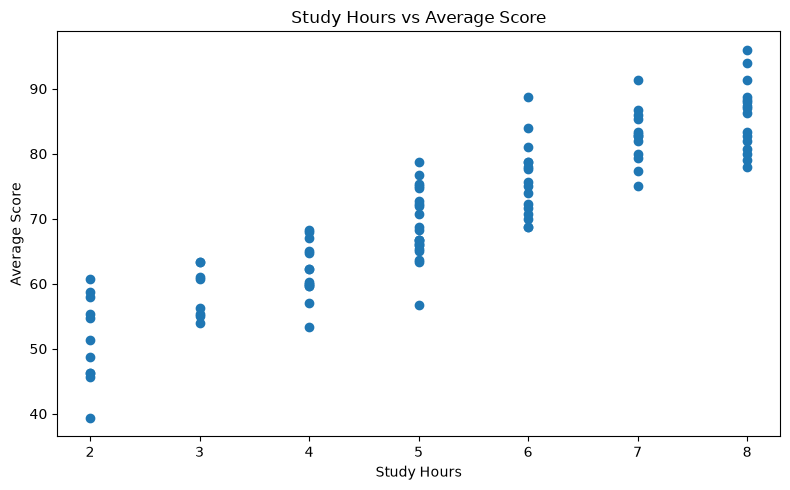

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Average_Score"])

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.tight_layout()

plt.savefig("../visualizations/study_hours_vs_score.png")
plt.show()

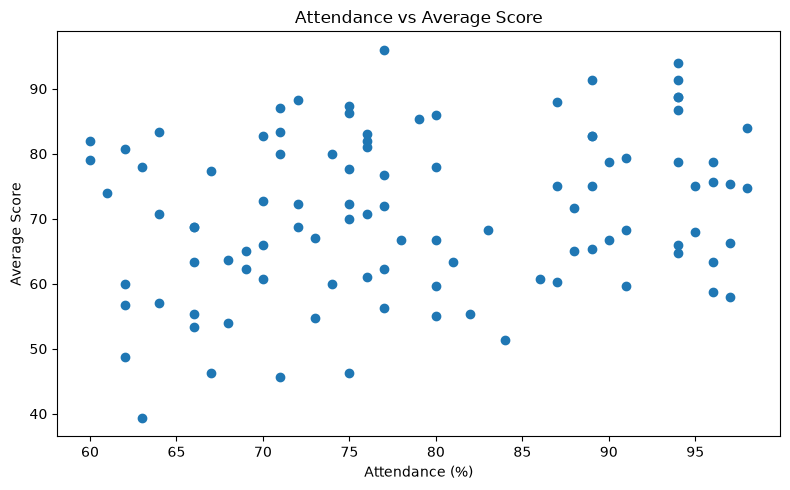

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Attendance"], df["Average_Score"])

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.tight_layout()

plt.savefig("../visualizations/attendance_vs_score.png")
plt.show()

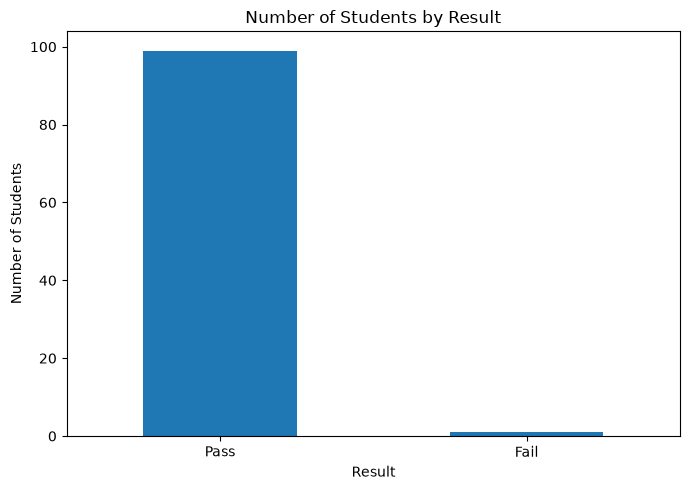

In [29]:
result_count = df["Result"].value_counts()

plt.figure(figsize=(7, 5))

result_count.plot(kind="bar")

plt.title("Number of Students by Result")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/students_by_result.png")
plt.show()